In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [10]:
df = pd.read_csv("D:\Shapefiles\Yield_Prediction_ENR_704\Farm_Phenology_TimeSeries_HighTemporal.csv")

# Convert date column
# df['date'] = pd.to_datetime(df['date'])

# # Sort values
# df = df.sort_values(['farm_id', 'date'])

print(df.columns)

Index(['system:index', 'B11', 'B12', 'B5', 'B6', 'B7', 'EVI', 'GNDVI', 'MSAVI',
       'NDRE', 'NDVI', 'NDVI_SG', 'NDWI', 'SAVI', 'date', 'id', 'latitude',
       'longitude', 'time', '.geo'],
      dtype='object')


<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\apoor\AppData\Local\Temp\ipykernel_12524\2333232816.py:1: SyntaxWarning: invalid escape sequence '\S'
  df = pd.read_csv("D:\Shapefiles\Yield_Prediction_ENR_704\Farm_Phenology_TimeSeries_HighTemporal.csv")


In [11]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['id', 'date'])

In [20]:
# VI_COLUMNS = ['EVI', 'GNDVI', 'MSAVI','NDRE','NDVI','NDVI_SG','NDWI', 'SAVI']
VI_COLUMNS = ['NDVI']

In [21]:
output_folder = "D:\\Shapefiles\\Yield_Prediction_ENR_704\\farm_plots"
os.makedirs(output_folder, exist_ok=True)

In [22]:
farms = df['id'].unique()

for farm in farms:
    
    farm_df = df[df['id'] == farm]

    plt.figure(figsize=(12,6))

    for vi in VI_COLUMNS:
        if vi in farm_df.columns:
            plt.plot(farm_df['date'], farm_df[vi], label=vi)

    plt.title(f"Vegetation Index Time Series - Farm {farm}")
    plt.xlabel("Date")
    plt.ylabel("Index Value")
    plt.legend()
    plt.grid()

    plt.savefig(f"{output_folder}/farm_{farm}_timeseries.png")
    plt.close()


In [23]:
for farm in farms:
    
    farm_df = df[df['id'] == farm]

    means = []

    for vi in VI_COLUMNS:
        if vi in farm_df.columns:
            means.append(farm_df[vi].mean())
        else:
            means.append(0)

    plt.figure(figsize=(8,5))
    plt.bar(VI_COLUMNS, means)

    plt.title(f"Seasonal Mean Indices - Farm {farm}")
    plt.ylabel("Mean Value")

    plt.savefig(f"{output_folder}/farm_{farm}_barplot.png")
    plt.close()


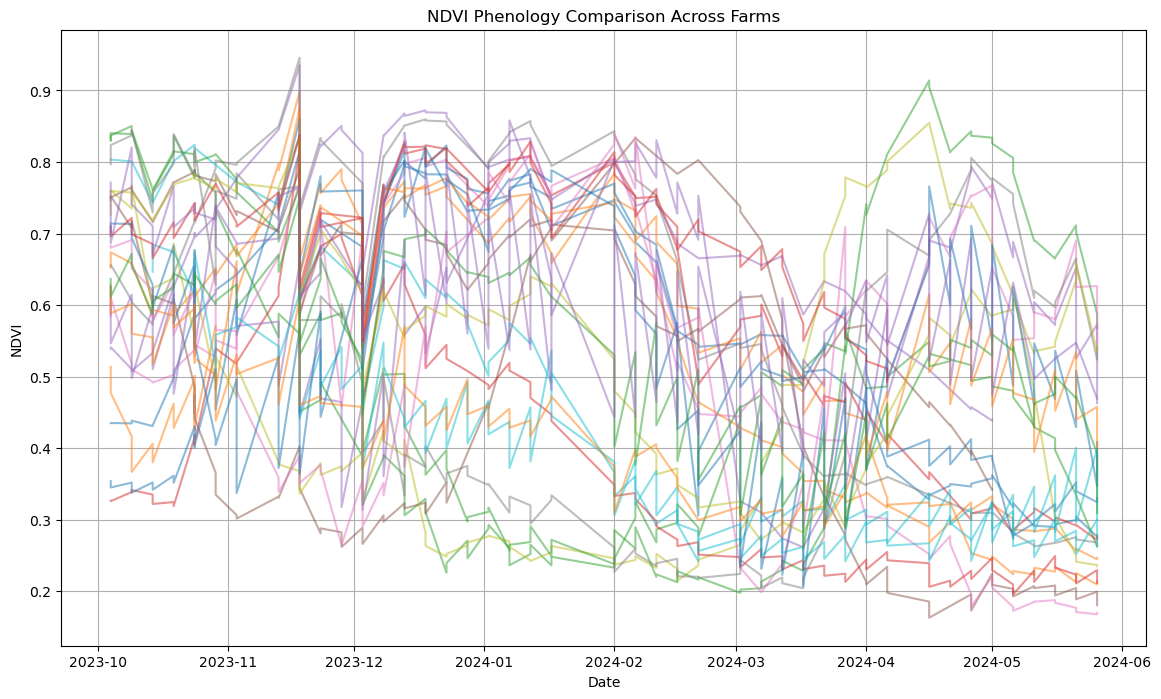

In [16]:
plt.figure(figsize=(14,8))

for farm in farms:
    farm_df = df[df['id'] == farm]
    plt.plot(farm_df['date'], farm_df['NDVI'], alpha=0.5)

plt.title("NDVI Phenology Comparison Across Farms")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.grid()

plt.show()
